In [ ]:
#pip install git+https://github.com/nignatiadis/empyrikos.git


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, matthews_corrcoef

from scipy.stats import ttest_1samp
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests
from matplotlib_venn import venn2
from scipy.stats import ttest_ind
import math
from scipy.stats import t
import empyrikos as eb

In [ ]:
import os, shutil, sys, subprocess, certifi

# Assure-toi d'installer côté kernel courant
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "empyrikos", "juliacall", "certifi"])

# Pointe juliacall vers la Julia installée par juliaup
os.environ["JULIA_EXE"] = shutil.which("julia")

# Corrige les certificats pour les téléchargements Python
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

# Vérif rapide
from juliacall import Main
print("Julia:", Main.seval("VERSION"))


In [15]:
phase2_df=pd.read_csv('/Users/imanemokhtatif/Desktop/Carnegie/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv',
                      low_memory=False)
#cts_light = ['20h_HL', '20h_ML']
# phase2_df['y2_slope_select'] = phase2_df[.apply(
#     lambda row: row['y2_slope'] if row['light_regime'] in cts_light else row['y2_slope_on'],
#     axis=1
# )]

wt = phase2_df[(phase2_df["mutated_genes"]=="WT") & phase2_df["plate"].astype(str).str.startswith("99")]
aug=[]
for i in range(1,4):
    for regime,g in wt.groupby("light_regime"):
        if len(g)>=3:
            base=g.sample(3,random_state=42).reset_index(drop=True)
            ids=[f"fake_mutant{i}1",f"fake_mutant{i}2",f"fake_mutant{i}3"]
            plates=[f"3{i-1}v1",f"3{i-1}v2",f"3{i-1}v3"]
            for k in range(3):
                for p in plates:
                    row=base.iloc[k].copy()
                    row["light_regime"]=regime
                    row["mutant_ID"]=ids[k]
                    row["mutated_genes"]=f"WT{i}"     # not "WT" → won’t be filtered out
                    row["plate"]=p
                    aug.append(row)
df_aug=pd.concat([phase2_df, pd.DataFrame(aug)], ignore_index=True)
#phase2_df = df_aug
phase2_df['y2_slope_select']= phase2_df['y2_slope']
phase2_df = phase2_df[~phase2_df['plate'].astype(str).str.startswith('99')]

In [16]:
phase2_df['plate'].unique()

array(['31v3', '32v1', '30v1', '30v3', '32v3', '32v2', '31v2', '30v1_1',
       '30v2', '30v1_2', '31v1', '30v3_1', '30v3_2'], dtype=object)

In [17]:
wt_df = phase2_df[phase2_df['mutant_ID'] == 'WT']
mutant_df = phase2_df[phase2_df['mutant_ID'] != 'WT']

# GENE

In [18]:
paired_gene_results = []

# group by gene and light regime
grouped = mutant_df.groupby(['mutated_genes', 'light_regime'])

for (gene, regime), group in grouped:
    # keep plate + value, drop missing
    group = group[['plate', 'y2_slope_select']].dropna()
    if group.empty:
        continue

    # for each plate, average all mutants of this gene (if multiple) -> one value per plate
    gene_plate_means = group.groupby('plate')['y2_slope_select'].mean()

    deltas = []
    for plate, gene_mean in gene_plate_means.items():
        # WT mean on the same plate & regime
        wt_vals = wt_df[
            (wt_df['light_regime'] == regime) &
            (wt_df['plate'] == plate)
        ]['y2_slope_select'].dropna()
        if wt_vals.empty:
            continue
        deltas.append(gene_mean - wt_vals.mean())

    # need at least 2 plates to estimate SEM
    if len(deltas) < 2:
        continue

    deltas = np.array(deltas, dtype=float)
    delta_mean = deltas.mean()
    se_hat = deltas.std(ddof=1) / np.sqrt(len(deltas))  # SEM of plate-level deltas

    paired_gene_results.append({
        'mutated_genes': gene,
        'light_regime': regime,
        'n_replicates': int(len(deltas)),   # number of plates used
        'delta_mean': float(delta_mean),
        'se_hat': float(se_hat)
    })

# DataFrame for R vash
paired_gene_df = pd.DataFrame(paired_gene_results)

In [19]:
paired_gene_df

,mutated_genes,light_regime,n_replicates,delta_mean,se_hat
0,Cre01.g000650,10min-10min,3,-0.001245,0.000246
1,Cre01.g000650,1min-1min,3,-0.002103,0.000667
2,Cre01.g000650,1min-5min,3,-0.000511,0.000479
3,Cre01.g000650,20h_HL,3,-0.003470,0.000444
4,Cre01.g000650,20h_ML,3,-0.001695,0.000094
...,...,...,...,...,...
4472,"unknown_chrom,Cre06.g302250",20h_HL,3,-0.003605,0.000531
4473,"unknown_chrom,Cre06.g302250",20h_ML,3,-0.000790,0.000481
4474,"unknown_chrom,Cre06.g302250",2h-2h,3,-0.000610,0.000313
4475,"unknown_chrom,Cre06.g302250",30s-30s,3,-0.002098,0.000273


In [20]:
# Prepare inputs for EPB
paired_gene_df = pd.DataFrame(paired_gene_results).copy()
paired_gene_df["df"] = paired_gene_df["n_replicates"] - 1
paired_gene_df["se_hat_sq"] = (paired_gene_df["se_hat"] ** 2)

# guard against zero/NaN SEs
paired_gene_df.loc[~np.isfinite(paired_gene_df["se_hat_sq"]) | (paired_gene_df["se_hat_sq"] <= 0), "se_hat_sq"] = 1e-12
paired_gene_df.loc[paired_gene_df["df"] < 1, "df"] = 1  

In [21]:

fits1 = {}          
rows = []

for regime, g in paired_gene_df.groupby("light_regime"):
    r = eb.epb_ttest(
        beta_hat=g["delta_mean"].to_numpy(),
        se_hat_squared=g["se_hat_sq"].to_numpy(),
        df=g["df"].to_numpy(),
        alpha=0.05,
    )
    fits1[regime] = r

    g = g.copy()
    g["p_value"] = getattr(r, "pvalues", np.nan)
    g["p_adj"]   = getattr(r, "adj_pvalues", np.nan)
    rows.append(g)

epb_by_regime1 = pd.concat(rows, ignore_index=True)


 iter        p_obj        d_obj |  abs_gap    x_feas    z_feas |      tau       kap        mu | dir_res     prox  step     alpha
    0   4.3597e-02  -1.5464e+02 | 1.42e+03  1.08e+02  1.40e+00 | 1.00e+00  1.00e+00  1.00e+00 |
    1  -2.2422e+00  -1.5973e+02 | 1.28e+03  1.10e+02  1.42e+00 | 8.83e-01  1.02e+00  9.00e-01 | 1.6e-12  3.5e-01  co-a  1.00e-01
    2  -5.2789e+00  -1.6420e+02 | 1.15e+03  1.11e+02  1.44e+00 | 7.87e-01  1.03e+00  8.10e-01 | 5.7e-13  2.4e-01  co-a  1.00e-01
    3  -9.1039e+00  -1.6869e+02 | 1.04e+03  1.12e+02  1.45e+00 | 7.05e-01  1.03e+00  7.29e-01 | 1.1e-12  6.1e-02  co-a  1.00e-01
    4  -2.9549e+01  -1.8839e+02 | 7.25e+02  1.12e+02  1.44e+00 | 4.94e-01  1.04e+00  5.10e-01 | 7.1e-13  6.5e-01  co-a  3.00e-01
    5  -8.0673e+01  -2.3895e+02 | 5.08e+02  1.12e+02  1.45e+00 | 3.45e-01  1.04e+00  3.58e-01 | 8.7e-13  5.0e-01  co-a  3.00e-01
    6  -1.8338e+02  -3.3968e+02 | 3.56e+02  1.12e+02  1.44e+00 | 2.42e-01  1.03e+00  2.51e-01 | 1.1e-12  3.2e-01  co-a  3.00e-01


In [24]:
epb_by_regime1.to_csv('significant_genes.csv')

In [23]:
#df = epb_by_regime1
def plot_volcano_grid(
    gene_stats,
    interesting_genes=None,
    fdr_threshold=0.05,
    effect_threshold=None,
    n_cols=4
):
    regimes = ["20h_HL","20h_ML","2h-2h","10min-10min","5min-5min","1min-5min","1min-1min","30s-30s"]#sorted(gene_stats['light_regime'].unique())
    n_rows = int(np.ceil(len(regimes) / n_cols))
    interesting_genes = set() if interesting_genes is None else set(interesting_genes)

    # couleurs stables
    unique_genes = sorted(interesting_genes)
    cmap = plt.cm.get_cmap('tab10', max(1, len(unique_genes)))
    gene_color_map = {gene: cmap(i % 10) for i, gene in enumerate(unique_genes)}

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, regime in enumerate(regimes):
        ax = axes[i]
        df = gene_stats[gene_stats['light_regime'] == regime].copy()
        df['neglog10_fdr'] = -np.log10(df['p_adj'].clip(lower=1e-300))
        df['effect_size']  = df['delta_mean']

        # 1) scatter tous en gris clair
        ax.scatter(df['effect_size'], df['neglog10_fdr'],
                   c='lightgray', alpha=0.6, s=20, edgecolors='none', zorder=1)

        # 2) scatter les gènes intéressants par-dessus
        if interesting_genes:
            sub = df[df['mutated_genes'].isin(interesting_genes)]
            ax.scatter(sub['effect_size'], sub['neglog10_fdr'],
                       c=sub['mutated_genes'].map(gene_color_map),
                       alpha=0.95, s=35, edgecolors='black', linewidths=0.3, zorder=3)

        # seuils
        ax.axhline(-np.log10(fdr_threshold), linestyle='--', color='black', linewidth=1, zorder=2)
        if effect_threshold is not None:
            ax.axvline(-abs(effect_threshold), linestyle='--', color='blue', linewidth=1, zorder=2)
            ax.axvline( abs(effect_threshold), linestyle='--', color='blue', linewidth=1, zorder=2)

        ax.set_title(f'{regime}')
        ax.set_xlabel('Effect Size (Mutant - WT)')
        if i % n_cols == 0:
            ax.set_ylabel('-log10(FDR adj)')
        ax.grid(True, alpha=0.2, zorder=0)

    # supprime axes vides
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # légende
    if interesting_genes:
        handles = [plt.Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=gene_color_map[g], markersize=8, label=g,
                              markeredgecolor='black', markeredgewidth=0.3)
                   for g in unique_genes]
        fig.legend(handles=handles, loc='center right', title="Fake Genes")

    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.suptitle('Volcano Plots by Light Regime (gene level t-test)', fontsize=16, y=1.02)
    plt.show()



/var/folders/_k/7_jrlrl97z33vpfdszcnhl780000gn/T/ipykernel_3282/892678809.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(1, len(unique_genes)))


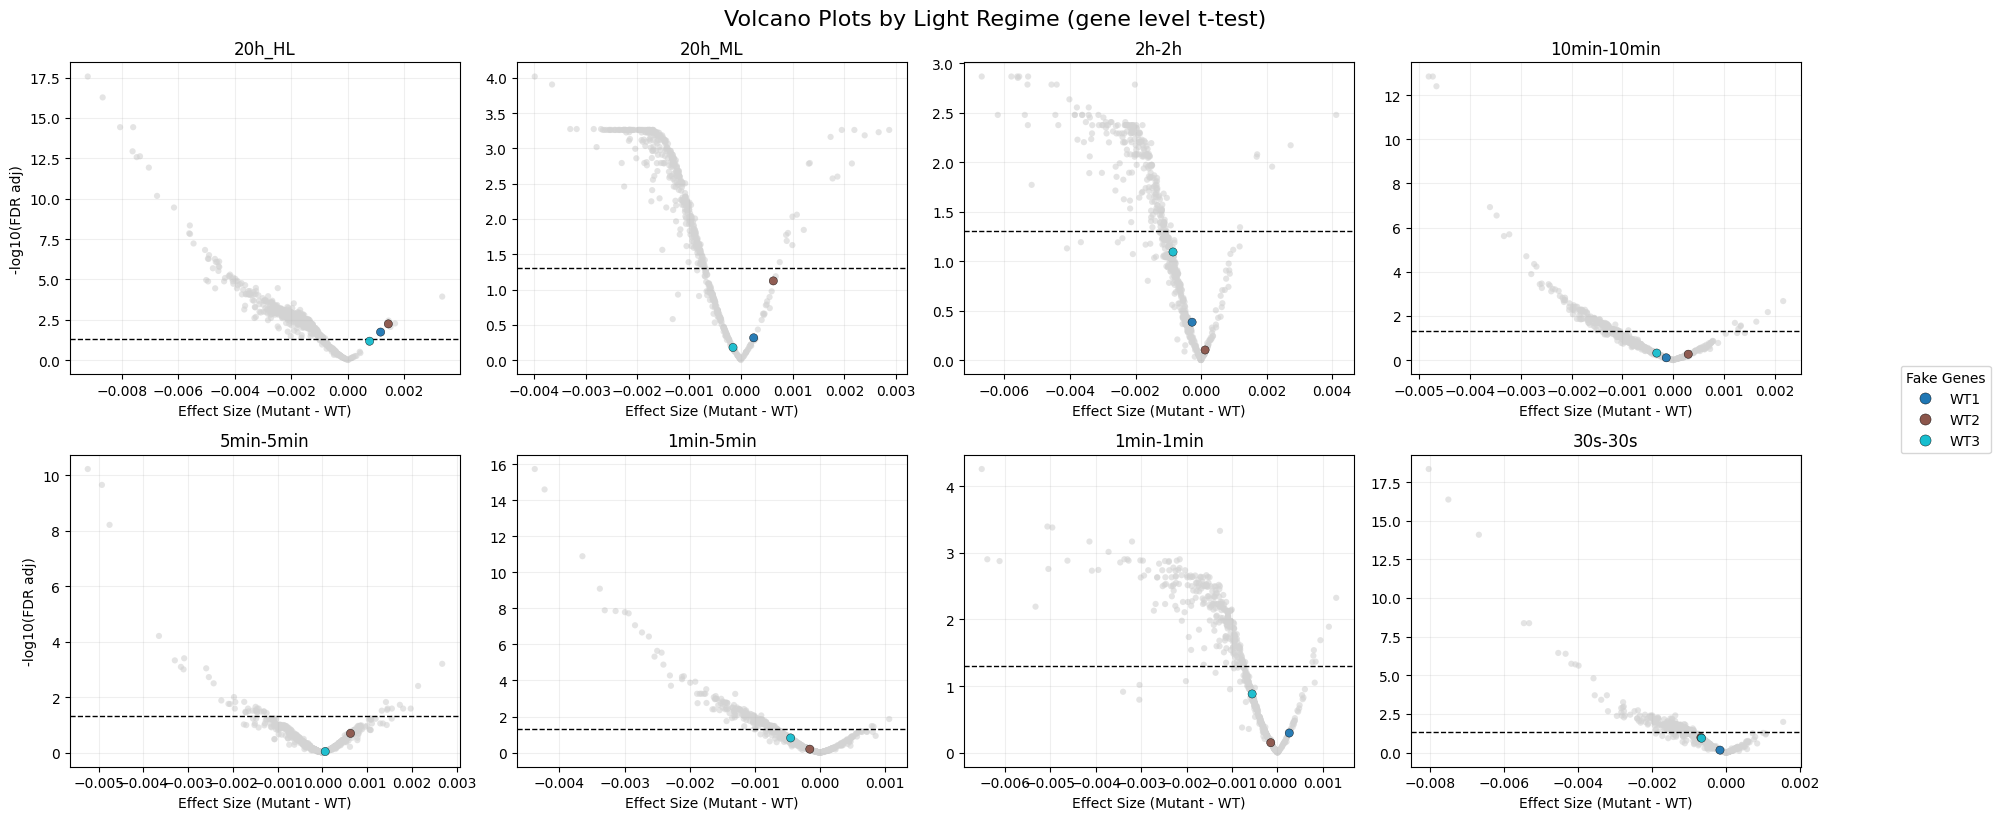

In [12]:

#interesting = [ "Cre12.g531900","Cre16.g661200","Cre07.g314800","Cre13.g588150", "Cre06.g278110","Cre05.g235800","Cre02.g105350","Cre13.g581900", "Cre07.g323450","Cre15.g635800" ]
interesting = [f"WT{i}"  for i in range(1,4)]
plot_volcano_grid(epb_by_regime1, interesting_genes=interesting, fdr_threshold=0.05, effect_threshold=None, n_cols=4)

# Mutant

In [ ]:
paired_mut_results = []

# group by gene and light regime
grouped = mutant_df.groupby(['mutant_ID', 'light_regime'])

for (gene, regime), group in grouped:
    # keep plate + value, drop missing
    group = group[['plate', 'y2_slope_select']].dropna()
    if group.empty:
        continue

    # for each plate, average all mutants of this gene (if multiple) -> one value per plate
    gene_plate_means = group.groupby('plate')['y2_slope_select'].mean()

    deltas = []
    for plate, gene_mean in gene_plate_means.items():
        # WT mean on the same plate & regime
        wt_vals = wt_df[
            (wt_df['light_regime'] == regime) &
            (wt_df['plate'] == plate)
        ]['y2_slope_select'].dropna()
        if wt_vals.empty:
            continue
        deltas.append(gene_mean - wt_vals.mean())

    # need at least 2 plates to estimate SEM
    if len(deltas) < 2:
        continue

    deltas = np.array(deltas, dtype=float)
    delta_mean = deltas.mean()
    se_hat = deltas.std(ddof=1) / np.sqrt(len(deltas))  # SEM of plate-level deltas

    paired_mut_results.append({
        'mutant_ID': gene,
        'light_regime': regime,
        'n_replicates': int(len(deltas)),   # number of plates used
        'delta_mean': float(delta_mean),
        'se_hat': float(se_hat)
    })

# DataFrame for R vash
paired_mut_df = pd.DataFrame(paired_mut_results)

In [ ]:
# Prepare inputs for EPB
paired_mut_df = pd.DataFrame(paired_mut_results).copy()
paired_mut_df["df"] = paired_mut_df["n_replicates"] - 1
paired_mut_df["se_hat_sq"] = (paired_mut_df["se_hat"] ** 2)

# guard against zero/NaN SEs
paired_mut_df.loc[~np.isfinite(paired_mut_df["se_hat_sq"]) | (paired_mut_df["se_hat_sq"] <= 0), "se_hat_sq"] = 1e-12
paired_mut_df.loc[paired_mut_df["df"] < 1, "df"] = 1  

In [ ]:

fits1 = {}          
rows = []

for regime, g in paired_mut_df.groupby("light_regime"):
    r = eb.epb_ttest(
        beta_hat=g["delta_mean"].to_numpy(),
        se_hat_squared=g["se_hat_sq"].to_numpy(),
        df=g["df"].to_numpy(),
        alpha=0.05,
    )
    fits1[regime] = r

    g = g.copy()
    g["p_value"] = getattr(r, "pvalues", np.nan)
    g["p_adj"]   = getattr(r, "adj_pvalues", np.nan)
    rows.append(g)

epb_by_regime1 = pd.concat(rows, ignore_index=True)


 iter        p_obj        d_obj |  abs_gap    x_feas    z_feas |      tau       kap        mu | dir_res     prox  step     alpha
    0   3.1212e-02  -2.9591e+02 | 2.45e+03  2.16e+02  1.68e+00 | 1.00e+00  1.00e+00  1.00e+00 |
    1  -1.1630e+00  -3.0118e+02 | 2.33e+03  2.19e+02  1.70e+00 | 9.37e-01  1.01e+00  9.50e-01 | 3.8e-12  9.3e-02  co-a  5.00e-02
    2  -2.6009e+00  -3.0428e+02 | 2.21e+03  2.21e+02  1.71e+00 | 8.85e-01  1.02e+00  9.03e-01 | 1.7e-12  1.4e-01  co-a  5.00e-02
    3  -6.1135e+00  -3.0860e+02 | 1.99e+03  2.21e+02  1.72e+00 | 7.94e-01  1.02e+00  8.12e-01 | 9.1e-13  4.2e-01  co-a  1.00e-01
    4  -1.0550e+01  -3.1402e+02 | 1.79e+03  2.22e+02  1.72e+00 | 7.12e-01  1.03e+00  7.31e-01 | 2.2e-12  8.1e-02  co-a  1.00e-01
    5  -1.6370e+01  -3.1998e+02 | 1.61e+03  2.22e+02  1.73e+00 | 6.40e-01  1.03e+00  6.58e-01 | 4.9e-12  3.6e-02  co-a  1.00e-01
    6  -5.1995e+01  -3.5488e+02 | 1.13e+03  2.22e+02  1.73e+00 | 4.48e-01  1.03e+00  4.61e-01 | 3.4e-12  8.6e-01  co-a  3.00e-01


In [ ]:
epb_by_regime1 

,mutant_ID,light_regime,n_replicates,delta_mean,se_hat,df,se_hat_sq,p_value,p_adj
0,LMJ.RY0402.038618,10min-10min,2,-0.000797,0.000179,1,3.189016e-08,0.096409,0.207919
1,LMJ.RY0402.038871,10min-10min,2,-0.001999,0.000583,1,3.393655e-07,0.001558,0.014680
2,LMJ.RY0402.039093,10min-10min,3,-0.001277,0.000345,2,1.188067e-07,0.013773,0.054383
3,LMJ.RY0402.039259,10min-10min,2,-0.000239,0.000881,1,7.759252e-07,0.650853,0.758034
4,LMJ.RY0402.039746,10min-10min,3,0.000288,0.000523,2,2.734982e-07,0.548082,0.680085
...,...,...,...,...,...,...,...,...,...
8595,fake_mutant22,5min-5min,3,0.000431,0.000125,2,1.571253e-08,0.274443,0.516683
8596,fake_mutant23,5min-5min,3,0.000111,0.000125,2,1.571253e-08,0.775525,0.887960
8597,fake_mutant31,5min-5min,3,0.000775,0.000247,2,6.082741e-08,0.056851,0.196901
8598,fake_mutant32,5min-5min,3,-0.000133,0.000247,2,6.082741e-08,0.736610,0.859779


In [ ]:
# df_epb : ton table (colonnes: mutant_ID, light_regime, delta_mean, p_adj, ...)
# df_map : table de mapping (colonnes: mutant_ID, gene) — une ligne par (mutant_ID, gene)

# 1) si un mutant a plusieurs gènes, choisis-en un (ex: le premier)
df_map_uniq = (phase2_df
               .dropna(subset=["mutant_ID","mutated_genes"])
               .drop_duplicates(["mutant_ID"])   # garde le 1er gène rencontré
               .rename(columns={"mutated_genes":"mutated_genes"}))

# 2) merge pour ajouter la colonne 'mutated_genes'
gene_stats = (epb_by_regime1 
              .merge(df_map_uniq[["mutant_ID","mutated_genes"]],
                     on="mutant_ID", how="left")
              .copy())

# 3) fallback si mapping manquant
gene_stats["mutated_genes"] = gene_stats["mutated_genes"].fillna("Unknown")


/var/folders/_k/7_jrlrl97z33vpfdszcnhl780000gn/T/ipykernel_2233/3820251863.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(1, len(unique_genes)))


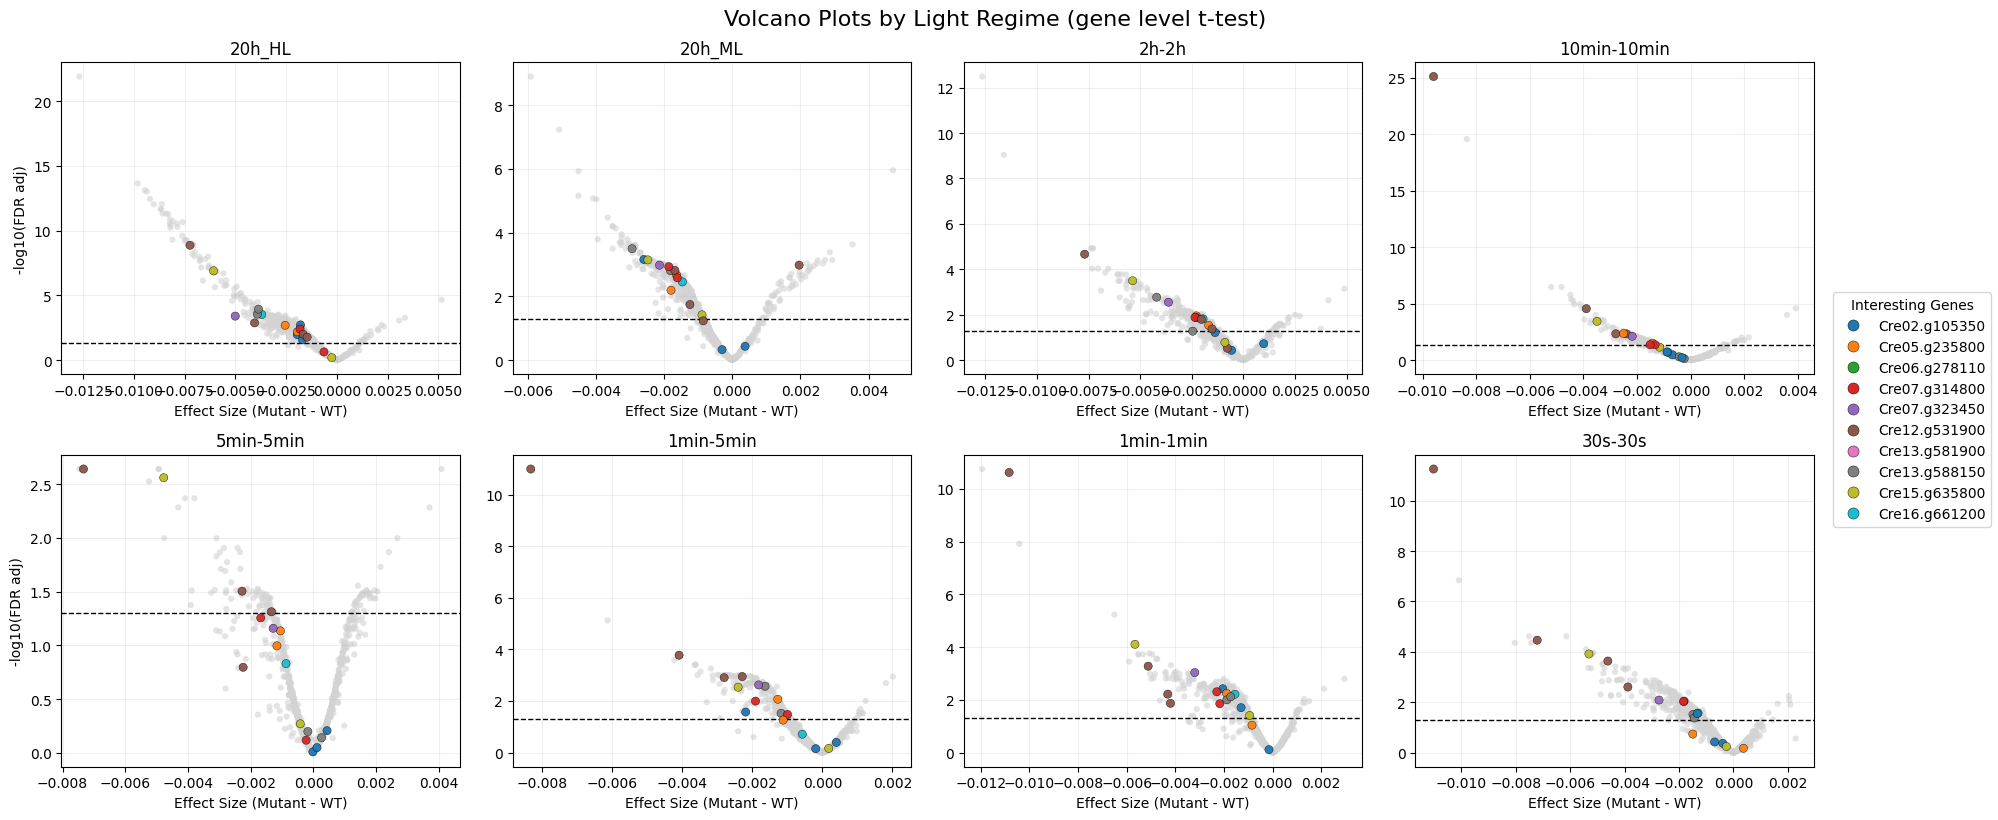

In [ ]:
interesting = [ "Cre12.g531900","Cre16.g661200","Cre07.g314800","Cre13.g588150", "Cre06.g278110","Cre05.g235800","Cre02.g105350","Cre13.g581900", "Cre07.g323450","Cre15.g635800" ]
#interesting = ["WT1","WT2","WT3"]
plot_volcano_grid(
    gene_stats, 
    interesting_genes=interesting,
    fdr_threshold=0.05,
    effect_threshold=None,
    n_cols=4
)


## GO term

In [ ]:
## See Go_test&Enrichment.ipynb